In [1]:
from kaggle_secrets import UserSecretsClient
user_secrets = UserSecretsClient()
hf_token = user_secrets.get_secret("HF_TOKEN")

# Set the token in the environment
import os
os.environ["HF_TOKEN"] = hf_token

In [2]:
!hf auth login --token $HF_TOKEN 

A new version of huggingface_hub (1.5.0) is available! You are using version 1.4.1.
To update, run: pip install -U huggingface_hub

The token has not been saved to the git credentials helper. Pass `add_to_git_credential=True` in this function directly or `--add-to-git-credential` if using via `hf`CLI if you want to set the git credential as well.
Token is valid (permission: write).
The token `AISC` has been saved to /root/.cache/huggingface/stored_tokens
Your token has been saved to /root/.cache/huggingface/token
Login successful.
Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.


In [3]:
!pip install -q transformers accelerate bitsandbytes torch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 33.1 MB/s eta 0:00:00:00:0100:01


# "Needle-in-a-Haystack" test

Testing the fundamental capability of long-context models to retrieve a fact buried in long context.

We will:

1. Generate a long synthetic document (e.g., 20k tokens)
2. Insert a unique fact at a chosen position
3. Ask the model to retrieve it
4. Repeat for different positions
5. Compute accuracy

In [4]:
import torch
import random
import gc
import matplotlib.pyplot as plt

from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig

In [5]:
TOTAL_TOKENS = 1000   # Increase to 16000 or 32000 later
POSITIONS = [0.1, 0.3, 0.5, 0.7, 0.9]
TRIALS_PER_POSITION = 3

MODELS = [
    "mistralai/Mistral-7B-v0.1",
    "meta-llama/Meta-Llama-3-8B",
    "Qwen/Qwen2-7B-Instruct"
]

In [6]:
def generate_long_context(tokenizer, total_tokens=8000, fact_position_ratio=0.5):

    filler_sentence = "The wind moved gently across the silent valley. "
    filler_block = filler_sentence * 20

    text_blocks = []
    while len(tokenizer.encode(" ".join(text_blocks))) < total_tokens:
        text_blocks.append(filler_block)

    unique_number = random.randint(100000, 999999)
    fact = f"\nIMPORTANT FACT: The secret code is {unique_number}.\n"

    insert_index = int(len(text_blocks) * fact_position_ratio)
    text_blocks.insert(insert_index, fact)

    full_text = " ".join(text_blocks)

    return full_text, str(unique_number)

In [7]:
def load_model(model_name):
    print(f"\nLoading {model_name} ...")

    tokenizer = AutoTokenizer.from_pretrained(model_name)

    # Configure 4-bit quantization
    bnb_config = BitsAndBytesConfig(
        load_in_4bit=True,
        bnb_4bit_quant_type="nf4", # Use "nf4" for better performance
        bnb_4bit_compute_dtype=torch.float16,
        bnb_4bit_use_double_quant=True,
    )

    model = AutoModelForCausalLM.from_pretrained(
        model_name,
        device_map="auto",
        quantization_config=bnb_config, # Pass the quantization config
        torch_dtype=torch.float16
    )

    return tokenizer, model

In [8]:
def ask_model(model, tokenizer, context, question):

    prompt = context + "\n\nQuestion: " + question + "\nAnswer:"

    inputs = tokenizer(prompt, return_tensors="pt").to(model.device)

    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=40,
            temperature=0.0,
            do_sample=False # Added to resolve the ValueError
        )

    output_text = tokenizer.decode(outputs[0], skip_special_tokens=True)

    return output_text

In [9]:
def evaluate_model(model_name):

    tokenizer, model = load_model(model_name)
    results = {}

    for pos in POSITIONS:
        correct_count = 0

        for _ in range(TRIALS_PER_POSITION):

            context, answer = generate_long_context(
                tokenizer,
                total_tokens=TOTAL_TOKENS,
                fact_position_ratio=pos
            )

            output = ask_model(
                model,
                tokenizer,
                context,
                "What is the secret code?"
            )

            if answer in output:
                correct_count += 1

        accuracy = correct_count / TRIALS_PER_POSITION
        results[pos] = accuracy
        print(f"Position {pos} → Accuracy {accuracy}")

    # Cleanup GPU
    del model
    del tokenizer
    gc.collect()
    torch.cuda.empty_cache()

    return results

In [10]:
all_results = {}

for model_name in MODELS:
    print(f"Testing model: {model_name}")

    results = evaluate_model(model_name)
    all_results[model_name] = results

Testing model: mistralai/Mistral-7B-v0.1

Loading mistralai/Mistral-7B-v0.1 ...


config.json:   0%|          | 0.00/571 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/996 [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

tokenizer.model:   0%|          | 0.00/493k [00:00<?, ?B/s]

...

Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/339 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/243 [00:00<?, ?B/s]

The following generation flags are not valid and may be ignored: ['temperature', 'top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


Position 0.1 → Accuracy 1.0
Position 0.3 → Accuracy 1.0
Position 0.5 → Accuracy 1.0
Position 0.7 → Accuracy 1.0
Position 0.9 → Accuracy 1.0


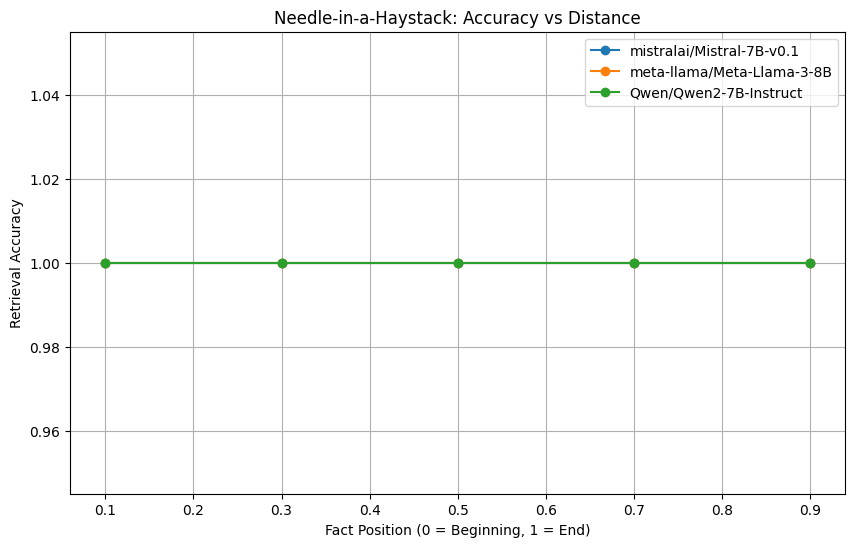

In [11]:
plt.figure(figsize=(10,6))

for model_name, results in all_results.items():

    distances = list(results.keys())
    accuracies = list(results.values())

    plt.plot(distances, accuracies, marker='o', label=model_name)

plt.xlabel("Fact Position (0 = Beginning, 1 = End)")
plt.ylabel("Retrieval Accuracy")
plt.title("Needle-in-a-Haystack: Accuracy vs Distance")
plt.legend()
plt.grid(True)
plt.show()

# Multi-hop Retrieval across Distance

We insert two dependent facts far apart in context, and ask the model to retrieve both facts, combine them and produce a derivative result.

In [12]:
def generate_multihop_context(tokenizer, total_tokens=8000, distance_ratio=0.5):

    filler_sentence = "The wind moved gently across the silent valley. "
    filler_block = filler_sentence * 20

    text_blocks = []
    while len(tokenizer.encode(" ".join(text_blocks))) < total_tokens:
        text_blocks.append(filler_block)

    # Fact A (early)
    fact_a = "\nElara hid the silver key in the observatory.\n"

    # Fact B (later)
    fact_b = "\nThe observatory was destroyed in the fire last night.\n"

    # Insert positions
    idx_a = int(len(text_blocks) * 0.1)
    idx_b = int(len(text_blocks) * (0.1 + distance_ratio))

    idx_b = min(idx_b, len(text_blocks)-1)

    text_blocks.insert(idx_a, fact_a)
    text_blocks.insert(idx_b, fact_b)

    full_text = " ".join(text_blocks)

    return full_text

In [13]:
def evaluate_multihop_model(model_name):

    tokenizer, model = load_model(model_name)

    distance_settings = [0.2, 0.4, 0.6, 0.8]
    results = {}

    for dist in distance_settings:
        correct_count = 0

        for _ in range(TRIALS_PER_POSITION):

            context = generate_multihop_context(
                tokenizer,
                total_tokens=TOTAL_TOKENS,
                distance_ratio=dist
            )

            output = ask_model(
                model,
                tokenizer,
                context,
                "Where is the silver key likely now?"
            )

            if "destroy" in output.lower() or "fire" in output.lower():
                correct_count += 1

        accuracy = correct_count / TRIALS_PER_POSITION
        results[dist] = accuracy

        print(f"Distance {dist} → Accuracy {accuracy}")

    del model
    del tokenizer
    gc.collect()
    torch.cuda.empty_cache()

    return results

In [14]:
multihop_results = {}

for model_name in MODELS:
    print(f"Multi-Hop Test: {model_name}")

    results = evaluate_multihop_model(model_name)
    multihop_results[model_name] = results

Multi-Hop Test: mistralai/Mistral-7B-v0.1

Loading mistralai/Mistral-7B-v0.1 ...


Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.


Distance 0.2 → Accuracy 1.0


Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.


...

Distance 0.6 → Accuracy 1.0


Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.


Distance 0.8 → Accuracy 1.0
Multi-Hop Test: Qwen/Qwen2-7B-Instruct

Loading Qwen/Qwen2-7B-Instruct ...


Loading weights:   0%|          | 0/339 [00:00<?, ?it/s]

Distance 0.2 → Accuracy 1.0
Distance 0.4 → Accuracy 1.0
Distance 0.6 → Accuracy 1.0
Distance 0.8 → Accuracy 1.0


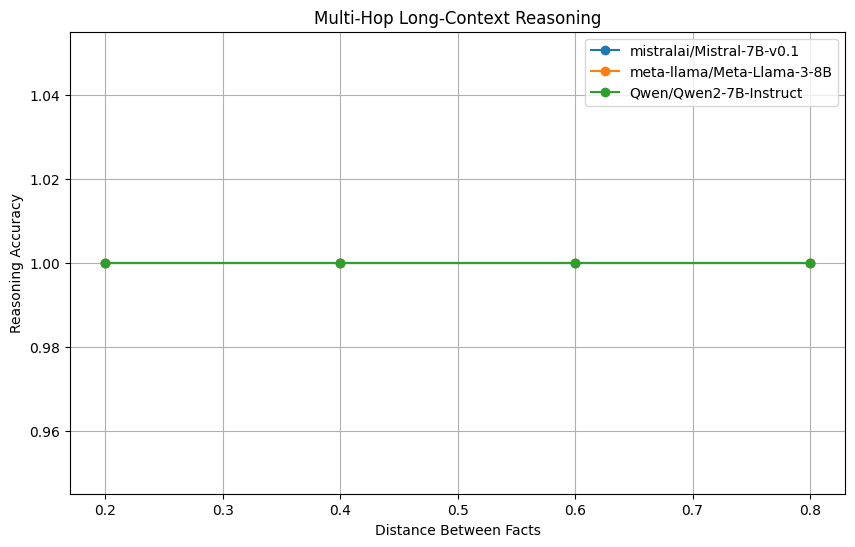

In [15]:
plt.figure(figsize=(10,6))

for model_name, results in multihop_results.items():
    distances = list(results.keys())
    accuracies = list(results.values())
    plt.plot(distances, accuracies, marker='o', label=model_name)

plt.xlabel("Distance Between Facts")
plt.ylabel("Reasoning Accuracy")
plt.title("Multi-Hop Long-Context Reasoning")
plt.legend()
plt.grid(True)
plt.show()

# Entity State Tracking & Update Consistency Test

It tests whether the model can track multiple characters, track changing attributes, handle later corrections / updates, override outdated information and avoid identity confusion.

In [16]:
def generate_entity_tracking_context(tokenizer, total_tokens=8000, num_characters=10, update_ratio=0.5):

    filler_sentence = "The wind moved gently across the silent valley. "
    filler_block = filler_sentence * 20

    text_blocks = []

    # Generate characters
    characters = [f"Character_{i}" for i in range(num_characters)]

    initial_states = {}
    updated_states = {}

    for char in characters:
        initial_states[char] = "alive"
        updated_states[char] = "dead"

    # Insert initial facts
    for char in characters:
        text_blocks.append(f"\n{char} is alive and lives in the eastern kingdom.\n")

    # Add filler until halfway
    while len(tokenizer.encode(" ".join(text_blocks))) < total_tokens * update_ratio:
        text_blocks.append(filler_block)

    # Update half of the characters
    killed_chars = random.sample(characters, num_characters // 2)

    for char in killed_chars:
        text_blocks.append(f"\n{char} was killed during the great war.\n")

    # Fill to total length
    while len(tokenizer.encode(" ".join(text_blocks))) < total_tokens:
        text_blocks.append(filler_block)

    full_text = " ".join(text_blocks)

    return full_text, killed_chars

In [17]:
def evaluate_entity_tracking(model_name):

    tokenizer, model = load_model(model_name)

    correct = 0
    total = 0

    for _ in range(TRIALS_PER_POSITION):

        context, killed_chars = generate_entity_tracking_context(
            tokenizer,
            total_tokens=TOTAL_TOKENS,
            num_characters=12,
            update_ratio=0.5
        )

        # Test both killed and alive characters
        test_chars = killed_chars + random.sample(
            [c for c in [f"Character_{i}" for i in range(12)] if c not in killed_chars],
            len(killed_chars)
        )

        for char in test_chars:

            output = ask_model(
                model,
                tokenizer,
                context,
                f"Is {char} alive? Answer yes or no."
            )

            output = output.lower()

            if char in killed_chars:
                if "no" in output:
                    correct += 1
            else:
                if "yes" in output:
                    correct += 1

            total += 1

    accuracy = correct / total
    print(f"Entity Tracking Accuracy: {accuracy}")

    del model
    del tokenizer
    gc.collect()
    torch.cuda.empty_cache()

    return accuracy

In [18]:
entity_tracking_results = {}

for model_name in MODELS:
    print(f"Entity Tracking Test: {model_name}")

    accuracy = evaluate_entity_tracking(model_name)
    entity_tracking_results[model_name] = accuracy

print("\nFinal Entity Tracking Results:")
print(entity_tracking_results)

Entity Tracking Test: mistralai/Mistral-7B-v0.1

Loading mistralai/Mistral-7B-v0.1 ...


Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for o

Entity Tracking Accuracy: 1.0
Entity Tracking Test: meta-llama/Meta-Llama-3-8B

Loading meta-llama/Meta-Llama-3-8B ...


Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for

Entity Tracking Accuracy: 1.0
Entity Tracking Test: Qwen/Qwen2-7B-Instruct

Loading Qwen/Qwen2-7B-Instruct ...


Loading weights:   0%|          | 0/339 [00:00<?, ?it/s]

Entity Tracking Accuracy: 1.0

Final Entity Tracking Results:
{'mistralai/Mistral-7B-v0.1': 1.0, 'meta-llama/Meta-Llama-3-8B': 1.0, 'Qwen/Qwen2-7B-Instruct': 1.0}
